## 1. Visualisation

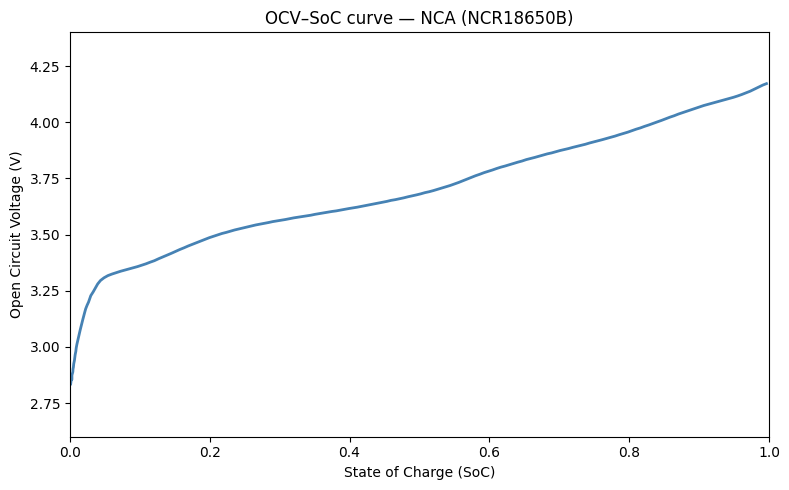

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

ocv_df = pd.read_csv('./OCV_SoC/OCV_SOC_NCA_1_folder/OCV_SOC_NCA_1.csv', header=None, names=['soc', 'ocv'])
ocv_df = ocv_df.sort_values('soc').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(ocv_df['soc'], ocv_df['ocv'], color='steelblue', lw=2)

ax.set_xlim(0, 1)
ax.set_ylim(2.6, 4.4)
ax.set_xlabel('State of Charge (SoC)')
ax.set_ylabel('Open Circuit Voltage (V)')
ax.set_title('OCV–SoC curve — NCA')

fig.tight_layout()
plt.show()

## 2. Sampling analysis

=== SoC sampling statistics (dx) ===


,n_points,n_steps,dx_min,dx_max,dx_mean,dx_median,dx_std,dx_range
0,190,189,0.000201,0.006045,0.005266,0.006045,0.001774,0.005843


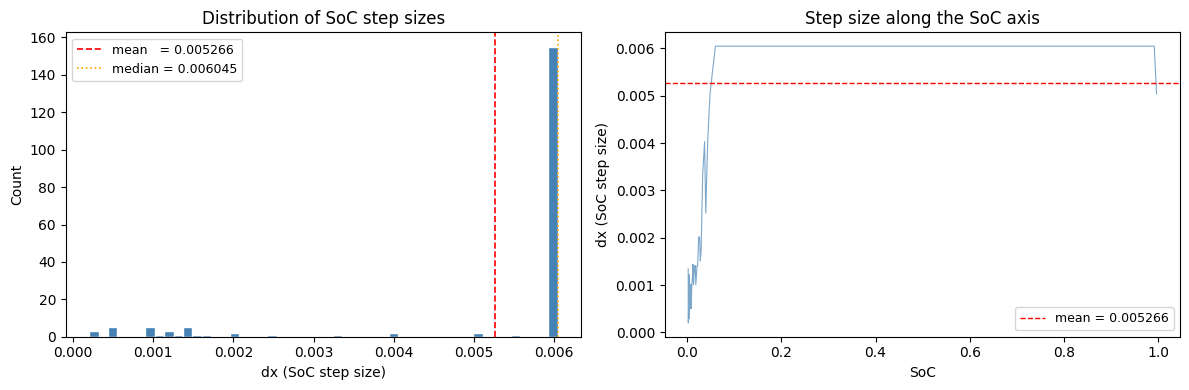

In [5]:
import numpy as np

# dx = distance between consecutive SoC points (already sorted)
dx = ocv_df['soc'].diff().dropna()

stats = pd.DataFrame([{
    'n_points':   len(ocv_df),
    'n_steps':    len(dx),
    'dx_min':     round(dx.min(),    8),
    'dx_max':     round(dx.max(),    8),
    'dx_mean':    round(dx.mean(),   8),
    'dx_median':  round(dx.median(), 8),
    'dx_std':     round(dx.std(),    8),
    'dx_range':   round(dx.max() - dx.min(), 8),
}])

print('=== SoC sampling statistics (dx) ===')
display(stats)

# --- Distribution plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(dx, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(dx.mean(),   color='red',    ls='--', lw=1.2, label=f'mean   = {dx.mean():.6f}')
axes[0].axvline(dx.median(), color='orange', ls=':',  lw=1.2, label=f'median = {dx.median():.6f}')
axes[0].set_xlabel('dx (SoC step size)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of SoC step sizes')
axes[0].legend(fontsize=9)

axes[1].plot(ocv_df['soc'].iloc[1:].values, dx.values,
             color='steelblue', lw=0.8, alpha=0.7)
axes[1].axhline(dx.mean(),   color='red',    ls='--', lw=1, label=f'mean = {dx.mean():.6f}')
axes[1].set_xlabel('SoC')
axes[1].set_ylabel('dx (SoC step size)')
axes[1].set_title('Step size along the SoC axis')
axes[1].legend(fontsize=9)

fig.tight_layout()
plt.show()